In [ ]:
import math, random
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw, ImageFont

In [ ]:
# Variables
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("DEVICE: ", device)
IMG_SIZE = 32
INPUT_IMG_CHANNELS = 3

EMBED_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
NUM_TRANSFORMER_BLOCKS = 4

EPOCHS = 50
LR = 3e-4
TEMPERATURE = 0.07

DEVICE:  cpu


SYNTHETIC DATASET

In [ ]:
# @title
colors = ['red','green','blue','yellow','purple','orange', 'pink', 'brown', 'gray']
shapes = ['square','circle','triangle']
positions = ['left','center','right', 'top', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']

Drawing image shapes

In [ ]:
# @title
def draw_sample(color, shape, position, img_size=IMG_SIZE):
    img = Image.new('RGB', (img_size, img_size), 'white')
    draw = ImageDraw.Draw(img)
    margin = 6
    w = h = img_size - 2*margin

    # Calculate x coordinates
    if 'left' in position:
        x0 = margin
        x1 = margin + w // 2
    elif 'top-left' in position:
        x0 = margin
        x1 = margin + w // 2
    elif 'bottom-left' in position:
        x0 = margin
        x1 = margin + w // 2
    elif 'right' in position:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'top-right' in position:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'bottom-right' in position:
        x0 = margin + w // 2
        x1 = img_size - margin
    else: # center or vertical positions
        x0 = margin + w // 4
        x1 = margin + 3 * w // 4

    # Calculate y coordinates
    if 'top' in position:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-left' in position:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-right' in position:
        y0 = margin
        y1 = margin + h // 2
    elif 'bottom' in position:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-left' in position:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-right' in position:
        y0 = margin + h // 2
        y1 = img_size - margin
    else: # center or horizontal positions
        y0 = margin + h // 4
        y1 = margin + 3 * h // 4

    if shape=='square':
        draw.rectangle([x0,y0,x1,y1], fill=color, outline='black')
    elif shape=='circle':
        draw.ellipse([x0,y0,x1,y1], fill=color, outline='black')
    else:  # triangle
        draw.polygon([((x1+x0)//2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')
    return img

In [ ]:
# @title
class ShapesDataset():
    def __init__(self):
        self.images = []
        self.captions = []

        # Generate all possible triplets
        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_sample(c, s, p) #image
                    cap = f"{c} {s} {p}" #corresponding caption
                    self.images.append((torch.from_numpy(np.asarray(img).copy())).permute(2,0,1).float()/255.0)
                    self.captions.append(cap)
        self.vocab, self.word2idx = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]'] + words
        w2i = {w:i for i,w in enumerate(vocab)}
        return vocab, w2i

    def encode_text(self, text):
        toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
        return torch.tensor(toks, dtype=torch.long)

    def __len__(self): return len(self.images)

    def __getitem__(self, i):
        return self.images[i], self.encode_text(self.captions[i]), self.captions[i]

# Create the full dataset
full_ds = ShapesDataset()
VOCAB_SIZE = len(full_ds.vocab)

In [ ]:
print(VOCAB_SIZE)

22


In [ ]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds) - train_size

print("Train DS: ", train_size)
print("Val DS: ", val_size)

train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])

Train DS:  194
Val DS:  49


Dataloader

In [ ]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

Display

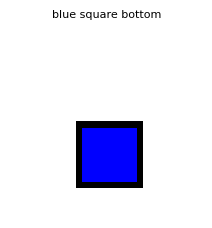

tensor([ 0,  1,  7, 15])


In [ ]:
imgs, _, caps = next(iter(train_loader))
idx = random.randint(0, len(imgs) - 1)
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8) # Convert to displayable image

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caps[idx], fontsize=8)
plt.axis('off')
plt.show()

print(_[1])

In [ ]:
images, text, x = next(iter(train_loader))
print(images.shape)
print(text.shape)
print(len(x))
print(text)
print(x)

torch.Size([12, 3, 32, 32])
torch.Size([12, 4])
12
tensor([[ 0, 21,  7,  3],
        [ 0,  1, 20,  6],
        [ 0, 14,  7,  3],
        [ 0, 13,  7, 15],
        [ 0,  1, 16,  4],
        [ 0,  1,  7,  4],
        [ 0, 11, 16, 18],
        [ 0,  9, 16, 15],
        [ 0, 14, 20,  3],
        [ 0, 12, 16,  6],
        [ 0,  5, 16, 15],
        [ 0,  8, 16,  2]])
('yellow circle bottom-left', 'blue triangle center', 'red circle bottom-left', 'purple circle right', 'blue square bottom-right', 'blue circle bottom-right', 'orange square top-left', 'green square right', 'red triangle bottom-left', 'pink square center', 'brown square right', 'gray square bottom')


In [ ]:
class ImageEncoder(nn.Module):
  def __init__(self):
      super().__init__()
      self.conv1 = nn.Conv2d(INPUT_IMG_CHANNELS, 16, 5)
      self.conv2 = nn.Conv2d(16, 32, 5)
      self.conv3 = nn.Conv2d(32, 64, 5)
      self.layer_norm = nn.LayerNorm(EMBED_DIM)

  def forward(self, x):
      x = F.relu(self.conv1(x))
      x = F.max_pool2d(x, 2)
      x = F.relu(self.conv2(x))
      x = F.max_pool2d(x, 2)
      x = self.conv3(x)
      x = x.flatten(1)
      # x = F.normalize(self.layer_norm(x), dim=-1)
      return x


In [ ]:
img_encoder = ImageEncoder()
encoded_image = img_encoder(images)
print(encoded_image.shape)
# encoded_output = encoded_output.flatten(1)
# print(encoded_output.shape)

torch.Size([12, 64])


In [ ]:
t = torch.tensor([[5,1,3,2,6]])
print(t.shape)
t = t.unsqueeze(1)
print(t.shape)

torch.Size([1, 5])
torch.Size([1, 1, 5])


In [ ]:
# Create a random tensor of shape (2, 3, 4)
t = torch.randn(2, 3, 4)
print("Random tensor shape:", t.shape)

t = t.unsqueeze(1)
print(t.shape)

t = t.unsqueeze(0)
print(t.shape)

t = t.squeeze(2)
print(t.shape)

t = t.flatten(1,2)
print(t.shape)

t = t.permute(2,1,0)
print(t.shape)

t= t.transpose(0,2)
print(t.shape)

# # Print the random tensor

# print("Random tensor content (first 2 rows):")
# print(random_tensor[:2])


Random tensor shape: torch.Size([2, 3, 4])
torch.Size([2, 1, 3, 4])
torch.Size([1, 2, 1, 3, 4])
torch.Size([1, 2, 3, 4])
torch.Size([1, 6, 4])
torch.Size([4, 6, 1])
torch.Size([1, 6, 4])


In [ ]:
class TextEncoder(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM, vocab_size = VOCAB_SIZE, sequence_len = 4, num_heads = ATTENTION_HEADS):
      super().__init__()
      self.token_embedding = nn.Embedding(vocab_size, embed_dim)
      self.position_embedding = nn.Embedding(sequence_len, embed_dim)
      # Set batch_first=True to expect input shape (batch_size, sequence_length, embed_dim)
      self.mha1 = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
      self.layer_norm1 = nn.LayerNorm(embed_dim)
      self.fc = nn.Linear(embed_dim*sequence_len, embed_dim)


  def forward(self, toks):
      token_embeddings = self.token_embedding(toks)
      # position_embeddings should be generated once, not per batch, or handle batching correctly
      # Create position_ids for the current batch's sequence length
      position_ids = torch.arange(token_embeddings.shape[1], device=toks.device) # use toks.device to match
      position_embeddings = self.position_embedding(position_ids)
      input_embeddings = token_embeddings + position_embeddings

      x = input_embeddings

      x, _ = self.mha1(x, x, x)
      x = self.layer_norm1(x)
      x = x.flatten(1)
      x = self.fc(x)

      return x

In [ ]:
print(text)

tensor([[ 0, 21,  7,  3],
        [ 0,  1, 20,  6],
        [ 0, 14,  7,  3],
        [ 0, 13,  7, 15],
        [ 0,  1, 16,  4],
        [ 0,  1,  7,  4],
        [ 0, 11, 16, 18],
        [ 0,  9, 16, 15],
        [ 0, 14, 20,  3],
        [ 0, 12, 16,  6],
        [ 0,  5, 16, 15],
        [ 0,  8, 16,  2]])


In [ ]:
textEncoder = TextEncoder()
encoded_text = textEncoder(text)
print(encoded_text.shape)
print(encoded_text[0])

torch.Size([12, 64])
tensor([ 5.1876e-01,  3.9767e-04, -3.1973e-01,  4.1296e-01,  6.0700e-01,
        -7.8163e-01,  9.8265e-01,  7.5186e-01,  7.0734e-01, -4.5224e-01,
         1.7987e-01,  5.1070e-01, -4.4962e-01,  3.8694e-01, -4.3775e-02,
         7.2125e-01, -8.1264e-02, -5.3484e-01,  1.1845e+00, -7.6780e-02,
        -4.0788e-01, -4.0709e-01,  5.5580e-02,  3.6065e-01,  2.8121e-01,
         4.4986e-01, -8.0565e-01,  8.9519e-02, -5.5025e-03,  9.6782e-01,
        -3.9620e-02, -5.3092e-01, -8.0620e-01,  5.7633e-01, -1.8942e-01,
         1.0901e-02, -5.7115e-01, -6.9676e-01,  4.4139e-01, -3.3803e-02,
        -6.3078e-01,  1.2454e+00,  1.0138e+00,  6.6431e-01, -8.0151e-01,
         3.4781e-01, -2.3420e-01, -1.1429e+00, -4.6034e-01, -6.0036e-01,
         1.5458e-01,  4.7980e-02,  8.8681e-01, -5.2502e-02, -1.5640e-01,
         4.4373e-02,  4.3039e-01,  1.2741e-01, -6.5430e-01,  2.9666e-01,
        -8.8720e-02, -4.0754e-01, -3.8227e-01, -7.9665e-01],
       grad_fn=<SelectBackward0>)


In [ ]:
def clip_loss(image_embedding, text_embedding, temperature=TEMPERATURE):
  clip_matrix = torch.matmul(image_embedding, text_embedding.T) / temperature
  ground_truth_matrix = torch.eye(clip_matrix.shape[0], device=clip_matrix.device)
  loss_i_t = 0
  loss_t_i =0


  for i in range(clip_matrix.shape[0]):
    logits_img = clip_matrix[i].unsqueeze(0)
    labels_img = ground_truth_matrix[i].unsqueeze(0)
    curr_loss_i_t = F.cross_entropy(logits_img, labels_img)
    # print("L(i2t) = ", curr_loss_i_t)
    loss_i_t += curr_loss_i_t

    logits_text = clip_matrix[:,i].unsqueeze(0)
    labels_text = ground_truth_matrix[:,i].unsqueeze(0)
    curr_loss_t_i = F.cross_entropy(logits_text, labels_text)
    # print("L(t2i) = ", curr_loss_t_i)
    loss_t_i += curr_loss_t_i

  loss_i_t /= image_embedding.shape[0]
  loss_t_i /= text_embedding.shape[0]

  clip_loss = 0.5*(loss_i_t + loss_t_i)

  return clip_loss


In [ ]:
loss = clip_loss(encoded_image, encoded_text)
print(loss)

tensor(3.9478, grad_fn=<MulBackward0>)


In [ ]:
image_encoder = ImageEncoder()
text_encoder = TextEncoder()
# criterion = clip_loss()
optimizer = torch.optim.Adam(list(image_encoder.parameters()) + list(text_encoder.parameters()), lr=LR)

In [ ]:
aggregated_train_losses = []
aggregated_val_losses = []
for epoch in range(EPOCHS):
  image_encoder.train()
  text_encoder.train()
  avg_train_loss = 0
  for images, captions, _ in train_loader:
    image_encodings = image_encoder(images)
    text_encodings = text_encoder(captions)
    optimizer.zero_grad()
    loss = clip_loss(image_encodings, text_encodings)
    loss.backward()
    optimizer.step()
    avg_train_loss += loss

  image_encoder.eval()
  text_encoder.eval()
  avg_val_loss = 0
  with torch.no_grad():
    for images, captions, _ in val_loader:
      image_encodings = image_encoder(images)
      text_encodings = text_encoder(captions)
      loss = clip_loss(image_encodings, text_encodings)
      avg_val_loss += loss


  avg_train_loss /= len(train_loader)
  avg_val_loss /= len(val_loader)
  aggregated_train_losses.append(avg_train_loss)
  aggregated_val_losses.append(avg_val_loss)
  print("Epoch: ", epoch, "Train Loss: ", avg_train_loss)
  print("Epoch: ", epoch, "Val Loss: ", avg_val_loss)
  print("**************************************")

Epoch:  0 Train Loss:  tensor(3.6125, grad_fn=<DivBackward0>)
Epoch:  0 Val Loss:  tensor(2.1164)
**************************************
Epoch:  1 Train Loss:  tensor(1.7239, grad_fn=<DivBackward0>)
Epoch:  1 Val Loss:  tensor(1.1890)
**************************************
Epoch:  2 Train Loss:  tensor(0.9822, grad_fn=<DivBackward0>)
Epoch:  2 Val Loss:  tensor(0.6437)
**************************************
Epoch:  3 Train Loss:  tensor(0.5399, grad_fn=<DivBackward0>)
Epoch:  3 Val Loss:  tensor(0.3648)
**************************************
Epoch:  4 Train Loss:  tensor(0.3492, grad_fn=<DivBackward0>)
Epoch:  4 Val Loss:  tensor(0.3546)
**************************************
Epoch:  5 Train Loss:  tensor(0.2592, grad_fn=<DivBackward0>)
Epoch:  5 Val Loss:  tensor(0.2851)
**************************************
Epoch:  6 Train Loss:  tensor(0.1632, grad_fn=<DivBackward0>)
Epoch:  6 Val Loss:  tensor(0.1734)
**************************************
Epoch:  7 Train Loss:  tensor(0.1840, gra

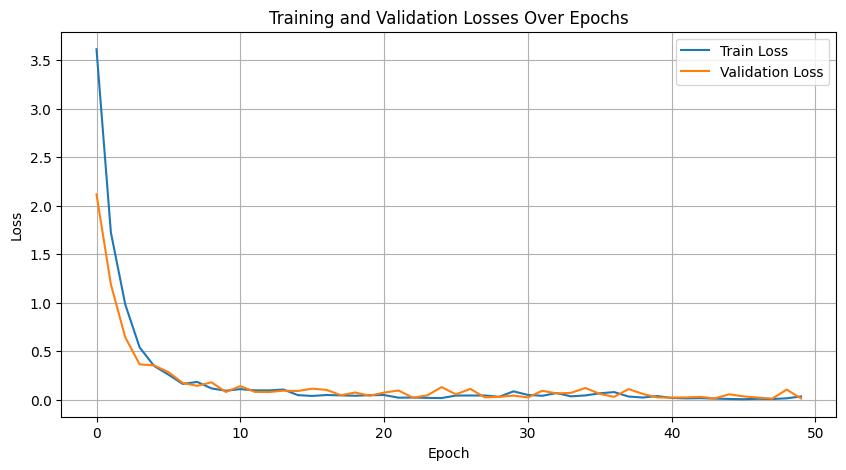

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot([loss.cpu().detach().numpy() for loss in aggregated_train_losses], label='Train Loss')
plt.plot([loss.cpu().detach().numpy() for loss in aggregated_val_losses], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def inference_image_to_caption(images, tokenized_captions, string_captions, idx):
  print(string_captions[idx]) # Print the true string caption
  image_encodings = image_encoder(images)
  text_encodings = text_encoder(tokenized_captions)

  clip_matrix = image_encodings @ text_encodings.T

  row_clip = clip_matrix[idx]
  caption_idx = torch.argmax(row_clip)
  caption = string_captions[caption_idx] # Return the string caption
  return caption

In [ ]:
def inference_caption_to_image(images, tokenized_captions, string_captions, idx):
  image_encodings = image_encoder(images)
  text_encodings = text_encoder(tokenized_captions)

  clip_matrix = image_encodings @ text_encodings.T

  col_clip = clip_matrix[:,idx]
  inferred_image_idx = torch.argmax(col_clip)
  print("Correct Image prediction: ", inferred_image_idx == idx)
  return inferred_image_idx

red triangle top-right
red triangle top-right


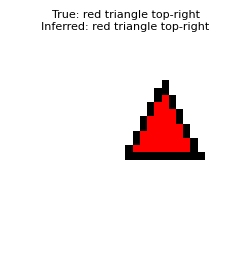

In [ ]:
image_encoder.eval()
text_encoder.eval()

# Get a batch of data from the validation loader
images_val, text_indices_val, captions_val = next(iter(val_loader))

# Select a random index for an image in the batch
idx = random.randint(0, len(images_val) - 1)
print(captions_val[idx])

# Get the image and its true caption
img_to_display = (images_val[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
true_caption = captions_val[idx]

# Infer the caption using the function, passing the string captions
inferred_caption = inference_image_to_caption(images_val.to(device), text_indices_val.to(device), captions_val, idx)

# Plot the image and display captions
plt.figure(figsize=(3, 3))
plt.imshow(img_to_display)
plt.title(f"True: {true_caption}\nInferred: {inferred_caption}", fontsize=8)
plt.axis('off')
plt.show()

In [ ]:
image_encoder.eval()
text_encoder.eval()

# Get a batch of data from the validation loader
images_val, text_indices_val, captions_val = next(iter(val_loader))

# Select a random index for an image in the batch
idx = random.randint(0, len(images_val) - 1)

print("Input ID: ",idx)

inferred_idx = inference_caption_to_image(images_val.to(device), text_indices_val.to(device), captions_val, idx)
print("Inferred ID: ", inferred_idx)



Input ID:  5
Correct Image prediction:  tensor(True)
Inferred ID:  tensor(5)
